In [68]:
#data structures
import pandas as pd
import numpy as np

#machine learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler

#metrics (performace and machine learning scores)
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import time #used for seeing how long it takes to run programs

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [69]:
train_val = pd.read_csv('data/train_values.csv') #The data values of each building
train_labels = pd.read_csv('data/train_labels.csv') #labels of data as damage severity ('damage_grade')

test_val = pd.read_csv('data/test_values.csv') #data values of contest submition (our AI would have to guess this, 
#but we won't know their 'damage_grade' for sure until DrivenData releases the answers.

In [70]:
#We combine the features and target label for data sampling and other transformations
df = pd.merge(train_val, train_labels, on='building_id')

In [71]:
df.columns

Index(['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id',
       'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage',
       'land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'has_superstructure_adobe_mud',
       'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag',
       'has_superstructure_cement_mortar_stone',
       'has_superstructure_mud_mortar_brick',
       'has_superstructure_cement_mortar_brick', 'has_superstructure_timber',
       'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered',
       'has_superstructure_rc_engineered', 'has_superstructure_other',
       'legal_ownership_status', 'count_families', 'has_secondary_use',
       'has_secondary_use_agriculture', 'has_secondary_use_hotel',
       'has_secondary_use_rental', 'has_secondary_use_institution',
       'has_secondary_use_school', 'has_secondary_use_i

### Explanation of columns:

geo_level_1_id, geo_level_2_id, geo_level_3_id (type: int): geographic region in which building exists, from largest (level 1) to most specific sub-region (level 3). Possible values: level 1: 0-30, level 2: 0-1427, level 3: 0-12567.

count_floors_pre_eq (type: int): number of floors in the building before the earthquake.

age (type: int): age of the building in years.

area_percentage (type: int): normalized area of the building footprint.

height_percentage (type: int): normalized height of the building footprint.

land_surface_condition (type: categorical): surface condition of the land where the building was built. Possible values: n, o, t.

foundation_type (type: categorical): type of foundation used while building. Possible values: h, i, r, u, w.

roof_type (type: categorical): type of roof used while building. Possible values: n, q, x.

ground_floor_type (type: categorical): type of the ground floor. Possible values: f, m, v, x, z.

other_floor_type (type: categorical): type of constructions used in higher than the ground floors (except of roof). Possible values: j, q, s, x.

position (type: categorical): position of the building. Possible values: j, o, s, t.

plan_configuration (type: categorical): building plan configuration. Possible values: a, c, d, f, m, n, o, q, s, u.

has_superstructure_adobe_mud (type: binary): flag variable that indicates if the superstructure was made of Adobe/Mud.

has_superstructure_mud_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Stone.

has_superstructure_stone_flag (type: binary): flag variable that indicates if the superstructure was made of Stone.

has_superstructure_cement_mortar_stone (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Stone.

has_superstructure_mud_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Mud Mortar - Brick.

has_superstructure_cement_mortar_brick (type: binary): flag variable that indicates if the superstructure was made of Cement Mortar - Brick.

has_superstructure_timber (type: binary): flag variable that indicates if the superstructure was made of Timber.

has_superstructure_bamboo (type: binary): flag variable that indicates if the superstructure was made of Bamboo.

has_superstructure_rc_non_engineered (type: binary): flag variable that indicates if the superstructure was made of non-engineered reinforced concrete.

has_superstructure_rc_engineered (type: binary): flag variable that indicates if the superstructure was made of engineered reinforced concrete.

has_superstructure_other (type: binary): flag variable that indicates if the superstructure was made of any other material.

legal_ownership_status (type: categorical): legal ownership status of the land where building was built. Possible values: a, r, v, w.

count_families (type: int): number of families that live in the building.

has_secondary_use (type: binary): flag variable that indicates if the building was used for any secondary purpose.

has_secondary_use_agriculture (type: binary): flag variable that indicates if the building was used for agricultural purposes.

has_secondary_use_hotel (type: binary): flag variable that indicates if the building was used as a hotel.

has_secondary_use_rental (type: binary): flag variable that indicates if the building was used for rental purposes.

has_secondary_use_institution (type: binary): flag variable that indicates if the building was used as a location of any institution.

has_secondary_use_school (type: binary): flag variable that indicates if the building was used as a school.

has_secondary_use_industry (type: binary): flag variable that indicates if the building was used for industrial purposes.

has_secondary_use_health_post (type: binary): flag variable that indicates if the building was used as a health post.

has_secondary_use_gov_office (type: binary): flag variable that indicates if the building was used fas a government office.

has_secondary_use_use_police (type: binary): flag variable that indicates if the building was used as a police station.

has_secondary_use_other (type: binary): flag variable that indicates if the building was secondarily used for other purposes.

In [72]:
#Sorting by damage grade
dmg1 = df[df['damage_grade'] == 1]
dmg2 = df[df['damage_grade'] == 2]
dmg3 = df[df['damage_grade'] == 3]

   damage_grade 1  damage_grade 2  damage_grade 3
0           25124          148259           87218


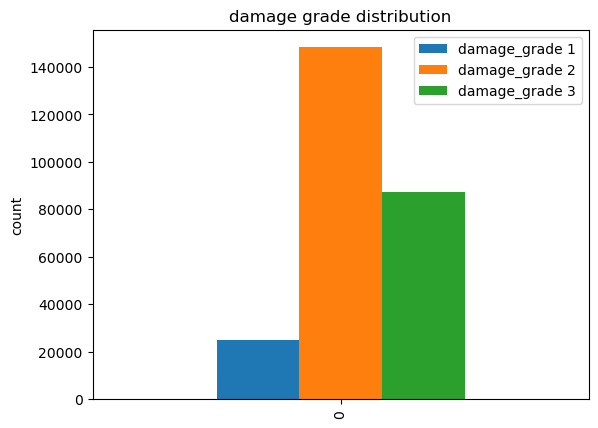

In [73]:
distribution = {
    # 'damage_grade 1': dmg1.size,
    # 'damage_grade 2': dmg2.size,
    # 'damage_grade 3': dmg3.size
    'damage_grade 1': len(dmg1),
    'damage_grade 2': len(dmg2),
    'damage_grade 3': len(dmg3)
}

# Create DataFrame
dist = pd.DataFrame(distribution, index=[0])

print(dist)
dist.plot(kind='bar')
plt.title('damage grade distribution')
# plt.yscale('log')
plt.ylabel('count')
plt.show()

In [74]:
# columnList = df.columns.tolist()
# columnList = df.select_dtypes(include='number').columns.tolist()
columnList = df.drop(['damage_grade', 'building_id', 'geo_level_1_id'], axis = 1).columns.tolist()
# columnList

In [94]:
columnList = df.drop(['damage_grade', 'building_id'], axis = 1).columns.tolist()

duplicates = df[df.duplicated(subset=columnList, keep=False)]
print(duplicates.shape)
mostCommon = (
    duplicates.groupby(columnList)['damage_grade']
      .agg(lambda x: x.value_counts().idxmax())
      .reset_index()
)
print(mostCommon.shape)
mostCommon.sort_values(by=columnList).head(10)

(28544, 40)
(12353, 39)


,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,0,69,3860,2,15,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,1
1,0,69,4203,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
2,0,81,7314,2,25,10,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
3,0,114,11078,2,10,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
4,0,146,10071,2,25,6,4,t,r,n,...,0,0,0,0,0,0,0,0,0,2
5,0,146,11169,2,15,6,4,t,r,n,...,0,0,0,0,0,0,0,0,0,2
6,0,163,2376,2,15,7,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
7,0,163,6182,2,15,8,6,n,r,n,...,0,0,0,0,0,0,0,0,0,2
8,0,163,7170,2,10,7,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
9,0,163,10661,2,20,9,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2


(12353, 39)


,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,most_common_target
0,0,69,3860,2,15,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,1
1,0,69,4203,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
2,0,81,7314,2,25,10,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
3,0,114,11078,2,10,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
4,0,146,10071,2,25,6,4,t,r,n,...,0,0,0,0,0,0,0,0,0,2
5,0,146,11169,2,15,6,4,t,r,n,...,0,0,0,0,0,0,0,0,0,2
6,0,163,2376,2,15,7,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
7,0,163,6182,2,15,8,6,n,r,n,...,0,0,0,0,0,0,0,0,0,2
8,0,163,7170,2,10,7,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
9,0,163,10661,2,20,9,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2


In [80]:
result = duplicates.sort_values(by=columnList)

In [81]:
result.head(10)

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
118081,163439,0,69,3860,2,15,7,5,t,r,...,0,0,0,0,0,0,0,0,0,1
126590,332639,0,69,3860,2,15,7,5,t,r,...,0,0,0,0,0,0,0,0,0,3
60112,432961,0,69,4203,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
234763,862379,0,69,4203,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
143400,469377,0,81,7314,2,25,10,5,t,r,...,0,0,0,0,0,0,0,0,0,2
190503,758006,0,81,7314,2,25,10,5,t,r,...,0,0,0,0,0,0,0,0,0,2
88882,429605,0,114,11078,2,10,7,5,t,r,...,0,0,0,0,0,0,0,0,0,2
225612,990843,0,114,11078,2,10,7,5,t,r,...,0,0,0,0,0,0,0,0,0,2
48989,24140,0,146,10071,2,25,6,4,t,r,...,0,0,0,0,0,0,0,0,0,2
71936,297836,0,146,10071,2,25,6,4,t,r,...,0,0,0,0,0,0,0,0,0,2


In [82]:
# smallerColumnList = df.drop(['damage_grade', 'building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id'], axis = 1).columns.tolist()
# smallerDuplicates = df[df.duplicated(subset=smallerColumnList, keep=False)]
# smallerResult = smallerDuplicates.sort_values(by=columnList)
# smallerResult.info()

In [83]:
result.value_counts().head(40)

building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  count_floors_pre_eq  age  area_percentage  height_percentage  land_surface_condition  foundation_type  roof_type  ground_floor_type  other_floor_type  position  plan_configuration  has_superstructure_adobe_mud  has_superstructure_mud_mortar_stone  has_superstructure_stone_flag  has_superstructure_cement_mortar_stone  has_superstructure_mud_mortar_brick  has_superstructure_cement_mortar_brick  has_superstructure_timber  has_superstructure_bamboo  has_superstructure_rc_non_engineered  has_superstructure_rc_engineered  has_superstructure_other  legal_ownership_status  count_families  has_secondary_use  has_secondary_use_agriculture  has_secondary_use_hotel  has_secondary_use_rental  has_secondary_use_institution  has_secondary_use_school  has_secondary_use_industry  has_secondary_use_health_post  has_secondary_use_gov_office  has_secondary_use_use_police  has_secondary_use_other  damage_grade
17           3               1387   

In [84]:
groups = result.groupby(by=columnList)

In [85]:
groupSizes = groups.size().reset_index()
groupSizes

,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,0
0,0,69,3860,2,15,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
1,0,69,4203,2,10,6,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
2,0,81,7314,2,25,10,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
3,0,114,11078,2,10,7,5,t,r,n,...,0,0,0,0,0,0,0,0,0,2
4,0,146,10071,2,25,6,4,t,r,n,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12348,30,1179,8015,2,95,8,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
12349,30,1179,8015,2,95,9,6,t,r,n,...,0,0,0,0,0,0,0,0,0,3
12350,30,1179,11129,2,95,9,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2
12351,30,1179,11129,2,95,10,6,t,r,n,...,0,0,0,0,0,0,0,0,0,2


In [86]:
damageGroups = groupSizes.groupby(by=0)


In [87]:
# groupSizes = damageGroups.size().reset_index()
# groupSizes
groupSizes = damageGroups.unstack()
groupSizes

AttributeError: 'DataFrameGroupBy' object has no attribute 'unstack'